# Приоритизация гипотез для увеличения выручки и анализ A/B-теста

По условиям задания есть 9 гипотез по увеличению выручки интернет-магазина. Также были проведен A/B-тест гипотезы. Необходимо приоритизировать гипотезы и проанализировать результаты A/B-теста.

## Приоритизация гипотез

In [1]:
import pandas as pd
import scipy.stats as stats
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('hypothesis.csv')
with pd.option_context('display.max_colwidth', 120):
        display(data)

,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5


In [3]:
# фреймворк ICE для приоритизации гипотез
data['ICE'] = (
    data['Impact'] * data['Confidence'] / data['Efforts']
)

with pd.option_context('display.max_colwidth', 120):
        display(data[['Hypothesis', 'ICE']].sort_values('ICE', ascending=False).round(2))

,Hypothesis,ICE
8,"Запустить акцию, дающую скидку на товар в день рождения",16.20
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",13.33
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",11.20
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",8.00
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",7.00
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2.00
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",1.33
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",1.12
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",1.00


In [4]:
# фреймворк RICE для приоритизации гипотез
data['RICE'] = (
    data['Reach'] * data['Impact'] * data['Confidence'] / data['Efforts']
)

with pd.option_context('display.max_colwidth', 120):
        display(data[['Hypothesis', 'RICE', 'ICE']].sort_values('RICE', ascending=False).round(2))

,Hypothesis,RICE,ICE
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",112.0,11.20
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",56.0,7.00
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",40.0,13.33
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",40.0,8.00
8,"Запустить акцию, дающую скидку на товар в день рождения",16.2,16.20
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",9.0,1.12
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",4.0,2.00
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",4.0,1.33
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3.0,1.00


Приоритизация гипотез изменилась при применении RICE вместо ICE. Это связано с тем что при использовании метода RICE учитывается параметр Reach (оценка количества пользователей, которых затронет изменение). Данный параметр позволяет увеличить приоритет гипотизам с большим охватом пользователей.  

## Анализ A/B-теста

In [5]:
orders = pd.read_csv('/datasets/orders.csv')
visitors = pd.read_csv('/datasets/visitors.csv')
orders.info()
visitors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   transactionId  1197 non-null   int64 
 1   visitorId      1197 non-null   int64 
 2   date           1197 non-null   object
 3   revenue        1197 non-null   int64 
 4   group          1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      62 non-null     object
 1   group     62 non-null     object
 2   visitors  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


In [6]:
# проверка на дубликаты
print(visitors.duplicated().sum())
print(orders.duplicated().sum())

0
0


In [7]:
# замена формата дат 
visitors['date'] = visitors['date'].map(lambda x: dt.datetime.strptime(x, '%Y-%m-%d'))
orders['date'] = orders['date'].map(lambda x: dt.datetime.strptime(x, '%Y-%m-%d'))
orders.info()
visitors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   int64         
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 46.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      62 non-null     datetime64[ns]
 1   group     62 non-null     object        
 2   visitors  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB


In [8]:
# проверка количества пользователей в каждой группе
print('Количество пользователей в группе А -', orders[orders['group'] == 'A']['visitorId'].nunique())
print('Количество пользователей в группе B -', orders[orders['group'] == 'B']['visitorId'].nunique())

excBA = orders[orders['group'] == 'B']['visitorId'].nunique()/orders[orders['group'] == 'A']['visitorId'].nunique() - 1
print(f'Пользователей в группе B больше, чем в группе А на {excBA:.0%}')

# проверка наличия пользователей попавших в обе группы
visitorAB = pd.merge(orders[orders['group'] == 'A'], 
                     orders[orders['group'] == 'B'], 
                     how='inner', 
                     on=['visitorId'])

print('Количество пользователей попавших в обе группы -', visitorAB['visitorId'].nunique())

Количество пользователей в группе А - 503
Количество пользователей в группе B - 586
Пользователей в группе B больше, чем в группе А на 17%
Количество пользователей попавших в обе группы - 58


In [9]:
# удаление пользователей попавших в обе группы
orders = orders[np.logical_not(orders['visitorId'].isin(visitorAB['visitorId']))]
print('Количество пользователей в группе А после корректировки -', orders[orders['group'] == 'A']['visitorId'].nunique())
print('Количество пользователей в группе B после корректировки -', orders[orders['group'] == 'B']['visitorId'].nunique())

Количество пользователей в группе А после корректировки - 445
Количество пользователей в группе B после корректировки - 528


In [10]:
# проверка соответствия дат
print(visitors['date'].min(), visitors['date'].max())
print(orders['date'].min(), orders['date'].max())

2019-08-01 00:00:00 2019-08-31 00:00:00
2019-08-01 00:00:00 2019-08-31 00:00:00


В данных нет пропусков и дубликатов. Формат дат был изменен на datetime. 

### Кумулятивная выручка по группам

In [11]:
# рассчет кумулятивной выручки по группам
datesGroups = orders[['date','group']].drop_duplicates()

ordersAggregated = (
    datesGroups.apply(
        lambda x: orders[np.logical_and(orders['date'] <= x['date'], orders['group'] == x['group'])]
        .agg({'date' : 'max', 
              'group' : 'max', 
              'transactionId' : 'nunique', 
              'visitorId' : 'nunique', 
              'revenue' : 'sum'}), axis=1)
    .sort_values(by=['date','group'])
)

visitorsAggregated = (
    datesGroups.apply(
        lambda x: visitors[np.logical_and(visitors['date'] <= x['date'], visitors['group'] == x['group'])]
        .agg({'date' : 'max', 
              'group' : 'max', 
              'visitors' : 'sum'}), axis=1)
    .sort_values(by=['date','group'])
)


cumulativeData = ordersAggregated.merge(visitorsAggregated, left_on=['date', 'group'], right_on=['date', 'group'])
cumulativeData.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visitors']

display(cumulativeData.head(5)) 

,date,group,orders,buyers,revenue,visitors
0,2019-08-01,A,23,19,142779,719
1,2019-08-01,B,17,17,59758,713
2,2019-08-02,A,42,36,234381,1338
3,2019-08-02,B,40,39,221801,1294
4,2019-08-03,A,66,60,346854,1845


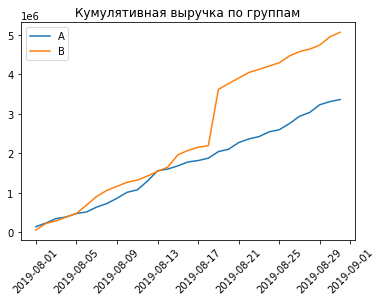

In [12]:
# график кумулятивной выручки по группам

# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе А
cumulativeRevenueA = cumulativeData[cumulativeData['group']=='A'][['date','revenue', 'orders']]

# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе B
cumulativeRevenueB = cumulativeData[cumulativeData['group']=='B'][['date','revenue', 'orders']]

plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue'], label='A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue'], label='B')

plt.legend() 
plt.title('Кумулятивная выручка по группам')
plt.xticks(rotation=45)
plt.show()

Выручка группы В больше выручки группы А. Также выручка равномерно увеличивается по обеим группам на протяжении всего теста, за исключением одного резкого скачка выручки в группе В. Это может обьясняться резким увеличением числа заказов или наличием очень дорогих заказов в выборке.

### Кумулятивный средний чек по группам

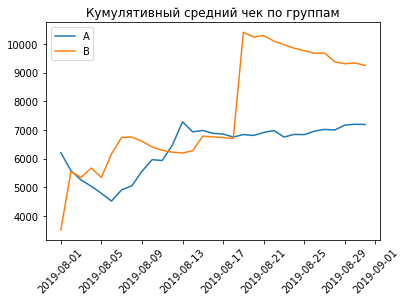

In [13]:
#график кумулятивного среднего чека по группам

plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue']/cumulativeRevenueA['orders'], label='A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue']/cumulativeRevenueB['orders'], label='B')
plt.legend() 
plt.title('Кумулятивный средний чек по группам')
plt.xticks(rotation=45)
plt.show()

Кумулятивный средний чек группы А установился к концу теста. Средний чек группы В резко вырос в середине теста, а потом начал снижаться. Скорее всего, в группу B в середине теста попали очень крупные заказы, что вызвало резкий скачек среднего чека.<br>
После резкого роста средний чек группы В становится больше среднего чека группы А и сохраняет преимущетсво до конца теста. 

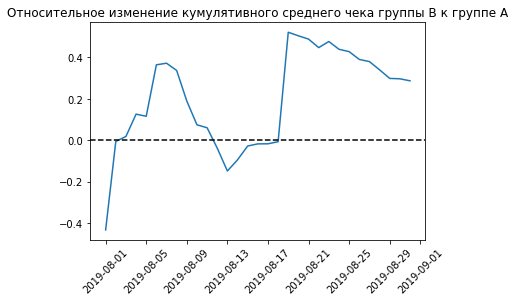

In [14]:
# график относительного изменения кумулятивного среднего чека группы B к группе A
# собираем данные в одном датафрейме
mergedCumulativeRevenue = cumulativeRevenueA.merge(cumulativeRevenueB, 
                                                   left_on='date', 
                                                   right_on='date', 
                                                   how='left', 
                                                   suffixes=['A', 'B'])

# cтроим отношение средних чеков
plt.plot(mergedCumulativeRevenue['date'], (mergedCumulativeRevenue['revenueB']
                                           /mergedCumulativeRevenue['ordersB'])
         /(mergedCumulativeRevenue['revenueA']/mergedCumulativeRevenue['ordersA'])-1)

plt.axhline(y=0, color='black', linestyle='--') 
plt.title('Относительное изменение кумулятивного среднего чека группы B к группе A')
plt.xticks(rotation=45)
plt.show()

Практически на протяжении всего теста средний чек группы В больше среднего чека группы А. В нескольких точках график резко «скачет». Вероятнее всего это связано с выбросами.<br>
Существенные колебания графика не позволяют однозначно сказать, что средний чек стабилизировался. На конец теста средний чек группы В больше среднего чека группы А, но есть тенденция к снижению преимущества группы В.

### Кумулятивная конверсия по группам

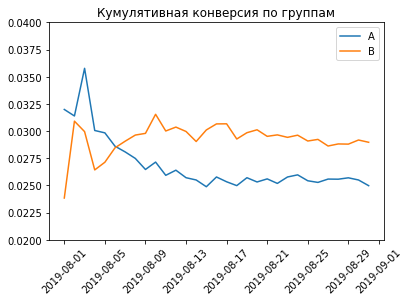

In [15]:
#график кумулятивной конверсии по группам

# считаем кумулятивную конверсию
cumulativeData['conversion'] = cumulativeData['orders']/cumulativeData['visitors']

# отделяем данные по группе A
cumulativeDataA = cumulativeData[cumulativeData['group']=='A']

# отделяем данные по группе B
cumulativeDataB = cumulativeData[cumulativeData['group']=='B']

# строим графики
plt.plot(cumulativeDataA['date'], cumulativeDataA['conversion'], label='A')
plt.plot(cumulativeDataB['date'], cumulativeDataB['conversion'], label='B')
plt.legend()
plt.title('Кумулятивная конверсия по группам')
plt.xticks(rotation=45)
plt.ylim([0.02, 0.04])
plt.show()

Конверсии групп имели значительные колебания в начале и зафиксировались к концу теста, при этом конверсия группы В больше конверсии группы А. 

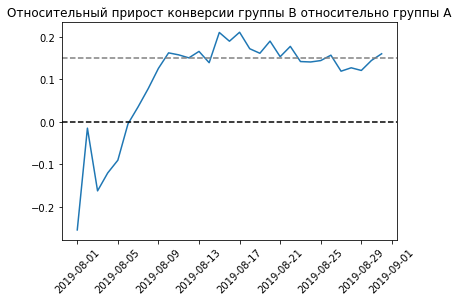

In [16]:
# Постройте график относительного изменения кумулятивной конверсии группы B к группе A. 
mergedCumulativeConversions = (
    cumulativeDataA[['date','conversion']].merge(cumulativeDataB[['date','conversion']], 
                                                 left_on='date', 
                                                 right_on='date', 
                                                 how='left', 
                                                 suffixes=['A', 'B'])
)
plt.plot(mergedCumulativeConversions['date'], 
         mergedCumulativeConversions['conversionB']/mergedCumulativeConversions['conversionA']-1)

plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=0.15, color='grey', linestyle='--')
plt.title('Относительный прирост конверсии группы B относительно группы A')
plt.xticks(rotation=45)
plt.show()

Группа В почти с начала теста показывала лучшую конверсию, чем группа А. В целом отношение конверсии ещё не установилось, и сейчас делать какие-либо выводы по тесту нельзя. 

### Количества заказов по пользователям

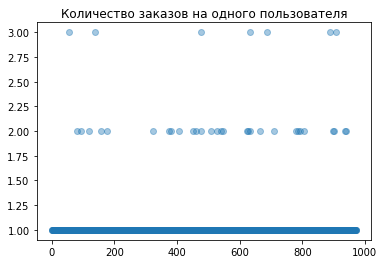

In [17]:
# точечный график количества заказов по пользователям
ordersByUsers = (
    orders.groupby('visitorId', as_index=False)
    .agg({'transactionId': 'nunique'})
)

ordersByUsers.columns = ['visitorId', 'orders']

x_values = pd.Series(range(0,len(ordersByUsers)))

plt.scatter(x_values, ordersByUsers['orders'], alpha = 0.4) 
plt.title('Количество заказов на одного пользователя')
plt.show()

У большинства пользователей 1-2 заказа. Пока не понятно какое количество заказов является аномалией, необходимо расчитать процентили.

In [18]:
# 95-й и 99-й перцентили количества заказов на пользователя
countOrdersMax = np.percentile(ordersByUsers['orders'], [95, 99])
print(countOrdersMax) 

[1. 2.]


Не более 5% пользователей оформляли больше чем 2 заказа. Таким образом, приймем 2 заказа на одного пользователя за верхнюю границу числа заказов, и отсеим аномальных пользователей по ней.

### Стоимость заказов

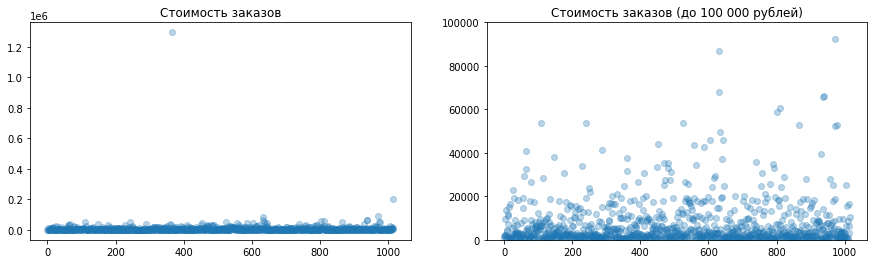

In [19]:
# точечный график стоимостей заказов
x_values = pd.Series(range(0,len(orders['revenue'])))

plt.figure(figsize=(15, 4))

plt.subplot(1, 2, 1)
plt.scatter(x_values, orders['revenue'], alpha=0.3) 
plt.title('Стоимость заказов')

plt.subplot(1, 2, 2)
plt.scatter(x_values, orders['revenue'], alpha=0.3) 
plt.title('Стоимость заказов (до 100 000 рублей)')
plt.ylim([0, 100000])
plt.show()

Всего два заказа существенно выделяются из общей массы. По графику сложно определить границу аномальных заказов.  Для точной цифры необходимо посчитать процентили.

In [20]:
# 95-й и 99-й перцентили стоимости заказов
print(np.percentile(orders['revenue'], [95, 99])) 
revenueMax = orders.revenue.quantile(.95).round(-4)

[26785. 53904.]


Установим границу отсечения аномальной выручки  - 30 000 рублей. Таким образом мы уберем от 1% до 5% пользователей с дорогими заказами. 

### Рассчет статистической значимости 

In [22]:
# статистическая значимость различий в среднем количестве заказов между группами по «сырым» данным

ordersByUsersA = (
    orders[orders['group'] == 'A']
    .groupby('visitorId', as_index=False)
    .agg({'transactionId': pd.Series.nunique})
)
ordersByUsersA.columns = ['visitorId', 'orders']

ordersByUsersB = (
    orders[orders['group'] == 'B']
    .groupby('visitorId', as_index=False)
    .agg({'transactionId': pd.Series.nunique})
)
ordersByUsersB.columns = ['visitorId', 'orders']

sampleA = pd.concat(
    [
        ordersByUsersA['orders'],
        pd.Series(
            0,
            index=np.arange(
                visitors[visitors['group'] == 'A']['visitors'].sum() - len(ordersByUsersA['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

sampleB = pd.concat(
    [
        ordersByUsersB['orders'],
        pd.Series(
            0,
            index=np.arange(
                visitors[visitors['group'] == 'B']['visitors'].sum() - len(ordersByUsersB['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

print(f'p-value: {stats.mannwhitneyu(sampleA, sampleB)[1]}')

print(f'Относительный прирост среднего числа заказов группы B: {sampleB.mean() / sampleA.mean() - 1:.1%}')

alpha = 0.05

if stats.mannwhitneyu(sampleA, sampleB)[1] < alpha:
    print('Отвергаем нулевую гипотезу: разница статистически значима')
else:
    print(
        'Не получилось отвергнуть нулевую гипотезу, вывод о различии сделать нельзя'
    ) 

p-value: 0.011018084110014696
Относительный прирост среднего числа заказов группы B: 16.0%
Отвергаем нулевую гипотезу: разница статистически значима


Нулевая гипотеза: статистически значимых различий в среднем числе заказов между группами нет. 
Альтернативная гипотеза: разница в среднем числе заказов между группами статистически значима.<br>
Р-value меньше 0.05, значит, нулевую гипотезу отвергаем, то есть различия в среднем числе заказов статистически значимы.
Среднее количество заказов в группе В на 16% больше, чем в группе А.

In [23]:
# статистическая значимость различий в среднем чеке заказа между группами по «сырым» данным

alpha = 0.05
pvalue = stats.mannwhitneyu(orders[orders['group']=='A']['revenue'], orders[orders['group']=='B']['revenue'])[1]
revenueMean = orders[orders['group']=='B']['revenue'].mean()/orders[orders['group']=='A']['revenue'].mean()-1

print(f'p-value: {pvalue}')
print(f'Относительный прирост среднего чека группы B: {revenueMean:.1%}')

if pvalue < alpha:
    print('Отвергаем нулевую гипотезу: разница статистически значима')
else:
    print('Не получилось отвергнуть нулевую гипотезу, вывод о различии сделать нельзя') 

p-value: 0.8294908998149533
Относительный прирост среднего чека группы B: 28.7%
Не получилось отвергнуть нулевую гипотезу, вывод о различии сделать нельзя


Нулевая гипотеза: статистически значимых различий в среднем чеке между группами нет. 
Альтернативная гипотеза: разница в среднем чеке между группами статистически значима.<br>
Нулевая гипотиза не опровергнута, то есть превышение среднего чека группы В на 28,7% нельзя считать статистически значимым.

In [24]:
# аномальные потребители
usersWithManyOrders = pd.concat(
    [
        ordersByUsersA[ordersByUsersA['orders'] > countOrdersMax[0]]['visitorId'],
        ordersByUsersB[ordersByUsersB['orders'] > countOrdersMax[0]]['visitorId'],
    ],
    axis=0,
)
usersWithExpensiveOrders = orders[orders['revenue'] > revenueMax]['visitorId']
abnormalUsers = (
    pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis=0)
    .drop_duplicates()
    .sort_values()
)
print(abnormalUsers.head(5))
print(abnormalUsers.shape[0]) 

1099    148427295
928     204675465
33      249864742
684     358944393
36      366673373
Name: visitorId, dtype: int64
77


In [25]:
# статистическая значимость различий в среднем количестве заказов между группами по «очищенным» данным
sampleAFiltered = pd.concat(
    [
        ordersByUsersA[
            np.logical_not(ordersByUsersA['visitorId'].isin(abnormalUsers))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                visitors[visitors['group'] == 'A']['visitors'].sum() - len(ordersByUsersA['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

sampleBFiltered = pd.concat(
    [
        ordersByUsersB[
            np.logical_not(ordersByUsersB['visitorId'].isin(abnormalUsers))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                visitors[visitors['group'] == 'B']['visitors'].sum() - len(ordersByUsersB['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
) 

pvalue = stats.mannwhitneyu(sampleAFiltered, sampleBFiltered)[1]

print(f'p-value: {pvalue}')

print(f'Относительный прирост среднего числа заказов группы B: {sampleBFiltered.mean() / sampleAFiltered.mean() - 1:.1%}')

alpha = 0.05

if pvalue < alpha:
    print('Отвергаем нулевую гипотезу: разница статистически значима')
else:
    print(
        'Не получилось отвергнуть нулевую гипотезу, вывод о различии сделать нельзя'
    ) 

p-value: 0.012548851852214262
Относительный прирост среднего числа заказов группы B: 18.0%
Отвергаем нулевую гипотезу: разница статистически значима


После удаления аномалий результаты по среднему количеству заказов практически не изменились. 

In [26]:
# статистическая значимость различий в среднем чеке заказа между группами по «очищенным» данным

alpha = 0.05

pvalue = (
    stats.mannwhitneyu(
    orders[np.logical_and(orders['group'] == 'A',
                          np.logical_not(orders['visitorId'].isin(abnormalUsers)))]['revenue'],
    orders[np.logical_and(orders['group'] == 'B',
                          np.logical_not(orders['visitorId'].isin(abnormalUsers)))]['revenue'])[1]
)

revenueMean = (
    orders[np.logical_and(orders['group'] == 'B',
                          np.logical_not(orders['visitorId'].isin(abnormalUsers)))]['revenue'].mean()/ 
    orders[np.logical_and(orders['group'] == 'A',
                          np.logical_not(orders['visitorId'].isin(abnormalUsers)))]['revenue'].mean() 
    - 1
)

print(f'p-value: {pvalue}')

print(f'Относительный прирост среднего чека группы B: {revenueMean:.1%}')

if pvalue < alpha:
    print('Отвергаем нулевую гипотезу: разница статистически значима')
else:
    print('Не получилось отвергнуть нулевую гипотезу, вывод о различии сделать нельзя') 

p-value: 0.8289783257478777
Относительный прирост среднего чека группы B: -1.1%
Не получилось отвергнуть нулевую гипотезу, вывод о различии сделать нельзя


После устранения аномалий р-value также больше 0,05, что также не позволяет отпровергнуть нулевую гипотезу о равенстве средних чеков. 
А средний чек группы В стал чуть меньше среднего чека группы А (по "сырым" данным - превышение группы В было 28,7%). 

## Вывод

1. Есть статистически значимое различие по среднему количеству заказов между группами и по «сырым», и по данным после фильтрации аномалий. Среднее количество заказов в группе В больше на 14,8%(без учета аномалий);
2. Нет статистически значимого различия по среднему чеку между группами ни по «сырым», ни по данным после фильтрации аномалий;
3. График различия конверсии между группами сообщает, что результаты группы В лучше группы А. 
4. График различия среднего чека говорит о том, что результаты группы B лучше почти на 15%. 

Учитывая данные факты, тест следует остановить и признать успешным. Группа В показывает лучшие результаты по количеству заказов на 1 пользователя и лучшую конверсию. Даже при одинаковом среднем чеке групп А и В выручка пользователей группы В будет больше за счет большего количества заказов каждого пользователя.